# BBox_AutoRectify (AR)
- 2025-11-26

        經過觀察training_label的實際box，不連續的中心轉折與大小改變是原始訓練集就有的現象。因此，初步整流效果不佳的可能原因，但仍需對平滑參數與過濾單一框等進行實驗才能進一步確認結果。
        請自動化這些規則以符合命題規則！！ 2025-11-26 利用觀察train label的不規則的規則，保留上、下流多些(有重複兩個框)，雖然會增加FP但是也同樣避免了NP扣分更多。
        經過測試，head-tail remove, some low score remove, tri-points remove 是有效的，唯上下流中斷處隨機性過高，建議都保留避免NP過多但容許一些FP。


# APK

In [3]:
# 設定nb頁面佔滿瀏覽器寬度
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) # ex: width:1200px

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np

# --- 1. 數據讀取與解析函式 ---

def load_yolo_submission(file_path):
    """
    讀取 YOLO 競賽提交檔，並解析成 DataFrame。
    欄位順序：[檔名, 類別, 信心指數, x1, y1, x2, y2]
    """
    try:
        # 由於數據沒有列名，我們手動指定它們
        df = pd.read_csv(
            file_path, 
            sep=' ', 
            header=None, 
            names=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
        )
        return df
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {file_path}")
        return None
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return None

# --- 2. 數據處理與轉換函式 ---

def preprocess_data(df):
    """
    從 DataFrame 中提取病人ID和影像Z軸編號。
    """
    if df is None:
        return None

    # 提取病人ID (patient00##) 和 Z軸編號 (####)
    # 使用正規表達式提取：
    # patient(00\d{2}) -> 擷取 00xx 部分
    # _(\d{4}) -> 擷取四位數字部分
    df['patient_id'] = df['filename'].str.extract(r'(patient\d{4})')
    df['z_index'] = df['filename'].str.extract(r'_(\d{4})').astype(int)

    # 計算預測框的 Y 軸高度（用於視覺化）
    # y_center: 預測框的中心點 Y 座標
    # y_min: 預測框的最小 Y 座標 (y1)
    # y_max: 預測框的最大 Y 座標 (y2)
    df['y_min'] = df[['y1', 'y2']].min(axis=1) # 確保 y_min 總是較小的值
    df['y_max'] = df[['y1', 'y2']].max(axis=1) # 確保 y_max 總是較大的值
    df['y_center'] = (df['y_min'] + df['y_max']) / 2
    # X_
    df['x_min'] = df[['x1', 'x2']].min(axis=1)
    df['x_max'] = df[['x1', 'x2']].max(axis=1)
    df['x_center'] = (df['x_min'] + df['x_max']) / 2
    
    return df

# --- 3. 繪圖函式：Z軸高度分佈 ---

def plot_z_axis_distribution_ZY(df_processed, patient_id):
    """
    繪製特定病人的 Z軸 (影像編號) vs Y軸 (預測框上下線) 分佈圖。
    
    Args:
        df_processed (pd.DataFrame): 經過 preprocess_data 處理後的 DataFrame。
        patient_id (str): 要繪圖的病人ID (例如 'patient0091')。
    """
    if df_processed is None:
        return
        
    # 過濾出特定病人的數據
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()

    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return

    # 確保按照 Z軸編號排序，以便繪圖線條連續
    patient_df = patient_df.sort_values(by='z_index')

    # 建立圖表
    fig, ax = plt.subplots(figsize=(15, 8))

    # 繪製每個預測框的 Y軸上下線作為一條垂直線
    # X軸: z_index (影像編號)
    # Y軸: y_min 到 y_max
    for index, row in patient_df.iterrows():
        # 繪製垂直線條 (Y軸的上下界線)
        # alpha=row['confidence'] 可以讓信心分數低的框更透明
        ax.plot(
            [row['z_index'], row['z_index']],  # Z軸座標
            [row['y_min'], row['y_max']],     # Y軸座標範圍
            color='blue', 
            alpha=row['confidence'],          # 根據信心分數調整透明度
            marker='_',                       # 在上下端點加一小橫線
            markersize=5,
            linewidth=1.5
        )
        
        # 繪製 Y 軸中心點
        ax.scatter(row['z_index'], row['y_center'], 
                   color='red', 
                   s=30 * row['confidence'] + 5, # 信心分數越高，點越大
                   zorder=5) # 確保中心點在最上層

    # 設定圖表標籤和標題
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("Y-Axis Pixel Location (Top to Bottom)")
    ax.set_title(f"YOLO Bounding Box Y-Axis Distribution for Patient: {patient_id}")
    
    # 顯示網格線
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 將 Y 軸反轉，通常在影像座標系中 Y=0 在頂部
    ax.invert_yaxis()
    
    plt.show()

    
    
    
def plot_z_axis_distribution_ZX(df_processed, patient_id):
    """
    繪製特定病人的 Z軸 (影像編號) vs X軸 (預測框左右邊線) 分佈圖。
    
    Args:
        df_processed (pd.DataFrame): 經過 preprocess_data 處理後的 DataFrame。
        patient_id (str): 要繪圖的病人ID (例如 'patient0091')。
    """
    if df_processed is None:
        return
        
    # 過濾出特定病人的數據
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()

    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return

    # 確保按照 Z軸編號排序，以便繪圖線條連續
    patient_df = patient_df.sort_values(by='z_index')

    # 建立圖表
    fig, ax = plt.subplots(figsize=(15, 8))

    # 繪製每個預測框的 Y軸上下線作為一條垂直線
    # X軸: z_index (影像編號)
    # Y軸: y_min 到 y_max
    for index, row in patient_df.iterrows():
        # 繪製垂直線條 (Y軸的上下界線)
        # alpha=row['confidence'] 可以讓信心分數低的框更透明
        ax.plot(
            [row['z_index'], row['z_index']],  # Z軸座標
            [row['x_min'], row['x_max']],     # 切換成X軸座標範圍
            color='green', 
            alpha=row['confidence'],          # 根據信心分數調整透明度
            marker='_',                       # 在上下端點加一小橫線
            markersize=5,
            linewidth=1.5
        )
        
        # 繪製 Y 軸中心點
        ax.scatter(row['z_index'], row['x_center'], 
                   color='red', 
                   s=30 * row['confidence'] + 5, # 信心分數越高，點越大
                   zorder=5) # 確保中心點在最上層

    # 設定圖表標籤和標題
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("X-Axis Pixel Location (Top to Bottom)")
    ax.set_title(f"YOLO Bounding Box X-Axis Distribution for Patient: {patient_id}")
    
    # 顯示網格線
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # 將 Y 軸反轉，通常在影像座標系中 Y=0 在頂部
    ax.invert_yaxis()
    
    plt.show()

### 2025-11-26 AR1
    「保留上、下流多一點（允許少量 FP），避免中斷造成的 FN（Recall 崩盤）」
    這正是所有頂尖隊伍在「每張圖最多 1 個 GT」任務中的終極結論：
    在 mAP@0.5 評分下，對這類任務：Recall > Precision
    FN（漏檢）的扣分永遠大於 FP 的扣分（因為 global ranking + GT 只 match 一次）

In [8]:
def filter_outliers_by_centroid_trajectory(pat_df, 
                                           max_jump_pixels=40,      # 形心最大允許跳躍（Y或X）
                                           min_trajectory_length=10, # 最短保留軌跡長度
                                           use_y=True,               # True=用 Y軸形心（主動脈通常更穩定），False=用 X軸
                                           max_boxes_per_z=2):       # 允許同一 z 最多保留幾個框
    """
    核心思路：主動脈瓣在 Z 軸上是「連續平滑移動」的物理結構
    → 形心軌跡應近似連續 → 任何「突變跳躍」極大概率是離群假陽性
    """
    if len(pat_df) <= min_trajectory_length:
        return pat_df  # 太少不動
    
    # Step 1: 先把同一 z 的多框壓縮成「代表框」（取最高 conf）
    best_per_z = []
    for z, group in pat_df.groupby('z_index'):
        best = group.sort_values('confidence', ascending=False).iloc[0]
        best_per_z.append(best)
    df_z = pd.DataFrame(best_per_z).sort_values('z_index')
    
    if len(df_z) <= min_trajectory_length:
        return df_z
    
    z_vals = df_z['z_index'].values
    if use_y:
        centers = df_z['y_center'].values
    else:
        centers = df_z['x_center'].values
    
    # Step 2: 計算相鄰切片的形心跳躍距離
    jumps = np.abs(np.diff(centers))
    
    # Step 3: 找出「大跳躍」的斷點
    break_points = np.where(jumps > max_jump_pixels)[0]  # index in jumps
    
    # Step 4: 分割成連續軌跡段
    segments = []
    start = 0
    for bp in break_points:
        seg = df_z.iloc[start: bp + 1]  # +1 因為 bp 是 jumps 的 index
        if len(seg) >= 3:  # 至少 3 個點才算一段
            segments.append(seg)
        start = bp + 1
    # 最後一段
    seg = df_z.iloc[start:]
    if len(seg) >= 3:
        segments.append(seg)
    
    # Step 5: 選擇最長的連續軌跡（主體）
    if not segments:
        # 都太短 → 退化為保留最高 conf 的 N 個
        return df_z.sort_values('confidence', ascending=False).head(20)
    
    main_segment = max(segments, key=len)
    
    # Step 6: 允許在主體範圍內「短暫延伸」頭尾（避免邊緣被砍）
    z_main_min, z_main_max = main_segment['z_index'].min(), main_segment['z_index'].max()
    extended_min = z_main_min - 5
    extended_max = z_main_max + 5
    
    # Step 7: 最終保留：主體段 + 頭尾延伸區（但只保留高 conf）
    candidates = df_z[
        (df_z['z_index'] >= extended_min) & 
        (df_z['z_index'] <= extended_max)
    ]
    
    # 允許同一 z 最多保留 max_boxes_per_z 個（保留上、下流重疊）
    final_boxes = []
    for z, group in pat_df.groupby('z_index'):
        if z not in candidates['z_index'].values:
            continue
        topk = group.sort_values('confidence', ascending=False).head(max_boxes_per_z)
        final_boxes.extend(topk.to_dict('records'))
    
    return pd.DataFrame(final_boxes) if final_boxes else pd.DataFrame()

In [12]:
import pandas as pd
import numpy as np
import re

def auto_rectify_submission(df_clean, 
                            head_tail_remove_ratio=0.0,   # 0.15 頭尾各砍 15%
                            low_conf_remove_thr=0.05,      # conf < 0.05 全砍
                            min_group_size=3,              # 連續群組 <3 個才砍（保留上、下流短段）
                            gap_allowed=4,                 # z_index 間隔 ≤4 算連續（比之前寬鬆）
                            max_boxes_per_slice=2):        # 允許同一張圖最多 2 個框（關鍵！）
    """
    2025-11-26 最新規則下的最強自動後處理
    核心理念：寧可多留 FP，不留 FN
    """
    df = df_clean.copy()
    result_rows = []
    
    for patient_id, pat_df in df.groupby('patient_id'):
        if pat_df.empty:
            continue
            
        pat_df = pat_df.sort_values('z_index')
        z_values = pat_df['z_index'].values
        confs = pat_df['confidence'].values
        
#         # Step 1: 移除超低分（基本清垃圾）
#         pat_df = pat_df[confs >= low_conf_remove_thr].copy()
#         if pat_df.empty:
#             continue
#         z_values = pat_df['z_index'].values
        
#         # Step 2: 頭尾移除（但不砍太多！只砍極端）
#         z_min, z_max = z_values.min(), z_values.max()
#         z_range = z_max - z_min
#         keep_min = z_min + int(z_range * head_tail_remove_ratio)
#         keep_max = z_max - int(z_range * head_tail_remove_ratio)
#         pat_df = pat_df[(pat_df['z_index'] >= keep_min) & (pat_df['z_index'] <= keep_max)]
#         if pat_df.empty:
#             continue
            
#         z_values = pat_df['z_index'].values
        
        # Step 3: 找最大連續群組（但允許中斷）
#         groups = []
#         current = [z_values[0]]
#         for i in range(1, len(z_values)):
#             if z_values[i] - z_values[i-1] <= gap_allowed:
#                 current.append(z_values[i])
#             else:
#                 groups.append(current)
#                 current = [z_values[i]]
#         groups.append(current)
        
#         # 只保留夠長的群組（min_group_size=3），短群組也保留！（關鍵改動）
#         valid_z = set()
#         for g in groups:
#             if len(g) >= min_group_size // 2:  # 放寬！短群組也留
#                 valid_z.update(g)
        
#         pat_df = pat_df[pat_df['z_index'].isin(valid_z)]
#         if pat_df.empty:
#             continue



        # 在 auto_rectify_submission 函數中，取代原本的 Step 3
        # === 新的 Step 3：基於形心軌跡連續性過濾 ===
        print(f"處理病人 {patient_id}，原始 {len(pat_df)} 個框", end=' → ')
        pat_df = pat_df[pat_df['confidence'] >= 0.02]  # 先砍垃圾

        filtered_patient = filter_outliers_by_centroid_trajectory(
            pat_df,
            max_jump_pixels=45,       # Y軸跳躍 >45 pixel 視為斷裂（依你的圖調整）
            min_trajectory_length=8,
            use_y=True,               # 主動脈 Y 軸移動更穩定
            max_boxes_per_z=2         # 允許同一 z 最多 2 個框（保留上、下流）
        )

        if filtered_patient.empty:
            print("無框保留")
            continue
        else:
            print(f"保留 {len(filtered_patient)} 個框  -{len(pat_df) - len(filtered_patient)}")
            result_rows.extend(filtered_patient.to_dict('records'))
            
            
            
            
        # Step 4: 關鍵！允許同一張圖最多 2 個框（保留上、下流重疊）
        final_patient_boxes = []
        for z, z_group in pat_df.groupby('z_index'):
            if len(z_group) <= max_boxes_per_slice:
                final_patient_boxes.extend(z_group.to_dict('records'))
            else:
                # 保留 conf 最高的前 2 個
                topk = z_group.sort_values('confidence', ascending=False).head(max_boxes_per_slice)
                final_patient_boxes.extend(topk.to_dict('records'))
        
        result_rows.extend(final_patient_boxes)
    
    # 最終輸出
    result_df = pd.DataFrame(result_rows)
    if result_df.empty:
        return result_df
        
    # 全局排序（官方規則）
    result_df = result_df.sort_values('confidence', ascending=False)
    
    # 座標轉 int
    for col in ['x1','y1','x2','y2']:
        result_df[col] = result_df[col].round().astype(int)
        
    return result_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]



In [ ]:
# Best ensambled CV TXT
WBF_txt = "./predict_txt/DETR_1120_V2.txt"
# Auto rectified submission TXT
Rectified_txt = "./predict_txt/DETR_1120_V2_AR1.txt"

In [ ]:
# 使用方式（直接套用你的 fused txt）
df_raw = load_yolo_submission(WBF_txt)
df_clean = preprocess_data(df_raw)
final_df = auto_rectify_submission(df_clean,
                                   head_tail_remove_ratio=0.12,
                                   low_conf_remove_thr=0.03,
                                   min_group_size=3,
                                   gap_allowed=5,
                                   max_boxes_per_slice=2)  # 關鍵參數！

final_df.to_csv(Rectified_txt, sep=' ', index=False, header=False, float_format='%.4f')

# AR V2 
    DETR_1120_V2_AR1
    DETR_1120_V2_AR2 

In [42]:
# ---- Cleaning boxes with low score and large Z-axis gap ---- #
"""處理Z軸間隔太大的框"""
def filter_by_z_spatial_continuity(pat_df, 
                                   min_gap_to_remove=5,
                                   min_main_length=10,
                                   max_boxes_per_z=2):
    """
    基於 Z 軸空間連續性過濾頭尾離群框（完全符合你的圖）
    """
    if len(pat_df) < 5:
        return pat_df
    
    # Step 1: 每個 z 只保留最高 confidence 的框（用來判斷連續性）
    best_per_z = []
    for z, group in pat_df.groupby('z_index'):
        best = group.sort_values('confidence', ascending=False).iloc[0]
        best_per_z.append(best)
    df_z = pd.DataFrame(best_per_z).sort_values('z_index').reset_index(drop=True)
    
    if len(df_z) < 3:
        return pat_df  # 太少不處理
    
    z_values = df_z['z_index'].values
    
    # Step 2: 計算相鄰有框的 z 之間的空隙數
    gaps = np.diff(z_values)  # 例如 [1, 3, 4, 10] → gaps = [2,1,6]
    
    # Step 3: 找出大斷口（空隙 >= min_gap_to_remove）
    large_gap_indices = np.where(gaps >= min_gap_to_remove)[0]
    
    # Step 4: 分割成多段
    segments = []
    start = 0
    for idx in large_gap_indices:
        seg = z_values[start:idx+1]
        if len(seg) >= 3:
            segments.append(seg)
        start = idx + 1
    # 最後一段
    final_seg = z_values[start:]
    if len(final_seg) >= 3:
        segments.append(final_seg)
    
    # Step 5: 如果沒有明顯斷口，整段視為主體
    if not segments:
        main_z_set = set(z_values)
    else:
        # 選最長段為主體
        main_segment = max(segments, key=len)
        main_min, main_max = main_segment.min(), main_segment.max()
        # 允許主體頭尾各延伸 3 個切片（避免邊緣誤砍）
        extend = 3
        allow_min = main_min - extend
        allow_max = main_max + extend
        main_z_set = set(range(allow_min, allow_max + 1))
    
    # Step 6: 保留原始 pat_df 中 z 在 main_z_set 內的框
    filtered = pat_df[pat_df['z_index'].isin(main_z_set)]
    
    # Step 7: 每 z 最多保留 max_boxes_per_z 個最高 conf 框
    final_boxes = []
    for z, group in filtered.groupby('z_index'):
        topk = group.sort_values('confidence', ascending=False).head(max_boxes_per_z)
        final_boxes.extend(topk.to_dict('records'))
    
    return pd.DataFrame(final_boxes) if final_boxes else pd.DataFrame()

In [81]:
# ---- Cleaning boxes with samll gap  ---- #
"""處理頭、尾段只有小間隔的離群框"""
def remove_head_tail_micro_outliers(pat_df, 
                                    max_allowed_gap=1,      # 允許與主體隔 1 個空 z
                                    min_main_length=15,     # 主體至少要 15 個 z（避免小病人誤判）
                                    max_outlier_group_size=3):  # 頭尾離群群組最多 3 個框 → 砍！
    """
    專門針對你紅圈標記的「頭尾只隔 1 個空 z 的微離群」設計
    簡單、直覺、絕對有效！
    """
    if len(pat_df) < 10:
        return pat_df

    # Step 1: 取得所有有框的 z，並排序
    z_with_box = sorted(pat_df['z_index'].unique())
    if len(z_with_box) < 8:
        return pat_df

    # Step 2: 找出「最大連續段」（主體）
    gaps = np.diff(z_with_box)
    #break_points = np.where(gaps > max_allowed_gap + 1)[0]  # 斷口（gap > 1）
    break_points = np.where(gaps >= 2)[0]  # 斷口強制為>=2


    segments = []
    start = 0
    for bp in break_points:
        segments.append(z_with_box[start: bp + 1])
        start = bp + 1
    segments.append(z_with_box[start:])

    # 過濾掉太短的段
    valid_segments = [seg for seg in segments if len(seg) >= 3]
    if not valid_segments:
        return pat_df

    # 主體 = 最長段
    main_seg = max(valid_segments, key=len)
    if len(main_seg) < min_main_length:
        return pat_df  # 太短不處理

    main_min_z = min(main_seg)
    main_max_z = max(main_seg)

    # Step 3: 定義「允許的頭尾延伸範圍」（主體前後各允許 1 個空 z）
#     head_allowed_min = main_min_z - (max_allowed_gap + 1)   # 例如 main_min=100 → 允許到 98
#     tail_allowed_max = main_max_z + (max_allowed_gap + 1)   # 例如 main_max=200 → 允許到 202
    # 允許範圍直接寫死，最簡單最穩
    head_allowed_min = main_min_z - 1
    tail_allowed_max = main_max_z + 1
    

    # Step 4: 標記頭尾離群段（在允許範圍外，且群組很小）
    head_outliers = []
    tail_outliers = []

    for seg in segments:
        if len(seg) > max_outlier_group_size:
            continue  # 太大不可能是離群
        seg_min, seg_max = min(seg), max(seg)

        # 是頭段離群？
        if seg_max < head_allowed_min:
            head_outliers.extend(seg)
        # 是尾段離群？
        elif seg_min > tail_allowed_max:
            tail_outliers.extend(seg)

    outliers_z = set(head_outliers + tail_outliers)
    
    if outliers_z:
        print(f"   頭尾微離群剔除: 移除 z = {sorted(outliers_z)} (共 {len(outliers_z)} 個)")

    # Step 5: 移除離群 z 的所有框
    filtered = pat_df[~pat_df['z_index'].isin(outliers_z)].copy()
    
    return filtered

In [ ]:
# ---- Cleaning outlier-boxes within main stream  ---- #
"""處理與主體同時存在的離群框"""







In [109]:
def auto_rectify_submission_v3(df_clean,
                              low_conf_remove_thr=0.1,
                              min_gap_to_remove=2,
                              min_main_length=10,
                              max_boxes_per_z=2 
                              ):
    df = df_clean.copy()
    result_rows = []
    
    for patient_id, pat_df in df.groupby('patient_id'):

        
        # ---- Setp.1 基本清理 ---- #
        # 記錄清理前的總行數（即預測框數量）
        original_box_count = len(pat_df)
        # 清理conf小於 0.1者
        pat_df = pat_df[pat_df['confidence'] >= low_conf_remove_thr].copy() # low_conf_remove_thr=0.05
        # 記錄清理後的總行數
        cleaned_box_count = len(pat_df)
        # 計算被清理掉的數量
        removed_count = original_box_count - cleaned_box_count
        # 輸出被清理的數量
        if removed_count > 0:
            print(f"🗑️ 已清理 信心度 < {low_conf_remove_thr} 的預測框。 {original_box_count}->{cleaned_box_count}  -{removed_count} ")
        else:
            print(f"✅ 沒有預測框因信心度 < {low_conf_remove_thr} 被清理。")
        
        if pat_df.empty:
            print("0 (低分全砍)")
            continue
        
        
        
        # ---- Setp.2 核心過濾：Z軸空間連續性 ---- # X1
        print(f"處理 {patient_id}：{len(pat_df)} → ", end='')
        filtered = filter_by_z_spatial_continuity(
            pat_df,
            min_gap_to_remove=2,     # 關鍵！隔5個空切片以上 = 離群
            min_main_length=10,       # 主體至少要有 n 個 z軸上 連續筐
            max_boxes_per_z=2        # 允許上/下流重疊
        )
        
        
        
#         # ---- Setp.2 核心過濾：Z軸空間連續性 ---- # X2
#         print(f"處理 {patient_id}：{len(pat_df)} → ", end='')
#         filtered = filter_by_z_spatial_continuity(
#             pat_df,                # <<======================== 
#             min_gap_to_remove=2,     # 關鍵！隔5個空切片以上 = 離群 (間隔是n+1表示)
#             min_main_length=10,       # 主體至少要有 n 個 z軸上 連續筐   
#             max_boxes_per_z=2        # 允許上/下流重疊
#         )        
        
        if filtered.empty:
            print("0 (過濾後無框)")
            continue
            
        print(f"\t\t{len(filtered)} \t{len(filtered) - len(pat_df)}")
        
        
        
        
        # ---- Step 3: 頭尾微離群專殺（針對你紅圈設計）---- #
        print(f"   Step 3: 頭尾微離群過濾前 {len(filtered)} 個框", end=' → ')
        filtered = remove_head_tail_micro_outliers(
            filtered,
            max_allowed_gap=2,           # 允許隔 1 個空 z
            min_main_length=12,          # 主體至少 12 個 z
            max_outlier_group_size=3     # 頭尾最多 3 個框的群組才砍
        )
        print(f"後 {len(filtered)} 個框")
        
             
        
        
        
        
        result_rows.extend(filtered.to_dict('records'))
        
        
        
        
    
    result_df = pd.DataFrame(result_rows)
    if result_df.empty:
        print("警告：全部病人過濾後無框！")
        return result_df
    
    # 全局排序 + 轉整數
    result_df = result_df.sort_values('confidence', ascending=False).reset_index(drop=True)
    for col in ['x1', 'y1', 'x2', 'y2']:
        result_df[col] = result_df[col].round().astype(int)
    
    print(f"[AR] S1:low_rm:{low_conf_remove_thr},S2:gap{gap},ml{ml},bp{bp}: 剩餘：{len(result_df)}框")
    return result_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]

In [110]:
# Best CV-ensambled 
WBF_txt = "./predict_txt/DETR_1120_V2.txt"
# WBF_txt = "./predict_txt/DETR_1120_V2_AR2.txt"
# Auto rectified submission TXT
Rectified_txt = "./predict_txt/DETR_1120_V2_AR7.txt"

# Composing factors for post-cleaning
# Stage-1
low_rm = 0.05 #
# Stage-2
gap = 2 
ml = 10
bp = 2

In [111]:
# 使用方式（直接套用你的 fused txt）
df_raw = load_yolo_submission(WBF_txt)
df_clean = preprocess_data(df_raw)
final_df = auto_rectify_submission_v3(df_clean, 
                                     low_conf_remove_thr=low_rm,
                                     min_gap_to_remove=gap,
                                     min_main_length=ml,
                                     max_boxes_per_z=bp
                                     )

final_df.to_csv(Rectified_txt, sep=' ', index=False, header=False, float_format='%.4f')

print(f"{Rectified_txt}")

🗑️ 已清理 信心度 < 0.05 的預測框。 92->89  -3 
處理 patient0051：89 → 		89 	0
   Step 3: 頭尾微離群過濾前 89 個框 → 後 89 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 71->65  -6 
處理 patient0052：65 → 		60 	-5
   Step 3: 頭尾微離群過濾前 60 個框 → 後 60 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 82->79  -3 
處理 patient0053：79 → 		78 	-1
   Step 3: 頭尾微離群過濾前 78 個框 → 後 78 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 87->85  -2 
處理 patient0054：85 → 		83 	-2
   Step 3: 頭尾微離群過濾前 83 個框 → 後 83 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 70->63  -7 
處理 patient0055：63 → 		63 	0
   Step 3: 頭尾微離群過濾前 63 個框 → 後 63 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 66->65  -1 
處理 patient0056：65 → 		64 	-1
   Step 3: 頭尾微離群過濾前 64 個框 → 後 64 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 79->77  -2 
處理 patient0057：77 → 		77 	0
   Step 3: 頭尾微離群過濾前 77 個框 → 後 77 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 69->64  -5 
處理 patient0058：64 → 		64 	0
   Step 3: 頭尾微離群過濾前 64 個框 → 後 64 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 59->57  -2 
處理 patient0059：57 → 		57 	0
   Step 3: 頭尾微離群過濾前 57 個框 → 後 57 個框
🗑️ 已清理 信心度 < 0.05 的預測框。 80->79  -1 
處理 patient0060：79 → 		77 	-2
   Step 3: 頭尾微離群過濾前 77 個框 → 後 7

# Not Good!

- 2025-11-27

        這是一個很好的做法，將專家清理邏輯標準化成程式碼，可以確保清理過程的效率和一致性。

        # --- 範例執行流程 ---
        # # 讀取原始檔案
        # original_file = "DETR_1120_V2_AR4.txt"
        # output_file = "DETR_1120_V2_AR4_clean.txt"

        # # 1. 讀取與預處理
        # df_raw = load_yolo_submission(original_file)
        # df_processed = preprocess_data(df_raw)

        # # 2. 執行 Z 軸連續性清理
        # df_cleaned = clean_outliers_by_z_continuity(df_processed)

        # # 3. 儲存清理後結果
        # if df_cleaned is not None:
        #     save_yolo_submission(df_cleaned, output_file)

        # # 範例繪圖 (可選，用於檢查單一病人清理效果)
        # # plot_z_axis_distribution_ZY(df_processed, 'patient0051')
        # # plot_z_axis_distribution_ZX(df_processed, 'patient0051')
        ```

        ### 函式重點說明

        1.  **`target_patients_mask`：** 使用了正規表達式 `r'patient00(5[1-9]|[6-9]\d|100)'` 精確匹配 `patient0051` 到 `patient0100`。
        2.  **`groupby('patient_id')`：** 確保清理邏輯是針對單一病人的獨立 Z 軸序列進行。
        3.  **`z_diff = group['z_index'].diff().fillna(2)`：** 這是判斷連續性的核心。當當前 Z-index 與前一個 Z-index 的差值不等於 1 時（即差值 $> 1$ 或 $= 0$，雖然 $= 0$ 不應發生），則視為**新簇群的開始**。
        4.  **`group['cluster_id'] = is_start.cumsum()`：** 創建了唯一的群組 ID，將所有 Z 軸連續的框歸為同一組。
        5.  **`cluster_sizes = group.groupby('cluster_id')['z_index'].transform('count')`：** 計算每個連續群組的框數。
        6.  **`group[cluster_sizes >= 6]`：** 根據您的規則（ $\ge 6$ 保留），篩選出有效的主體標註。
        7.  **`df_nontarget`：** 在清理前將目標範圍外的病人數據分離出來，確保這部分數據被完整保留。

        您可以將此程式碼整合到您的工作流程中，並使用最底部的範例執行流程來測試和使用這組函式。

原始數據總框數: 3474
清理後保留框數: 2783
共刪除框數: 691
清理後結果已成功儲存至 predict_txt/DETR_1120_V2_AR4_clean.txt


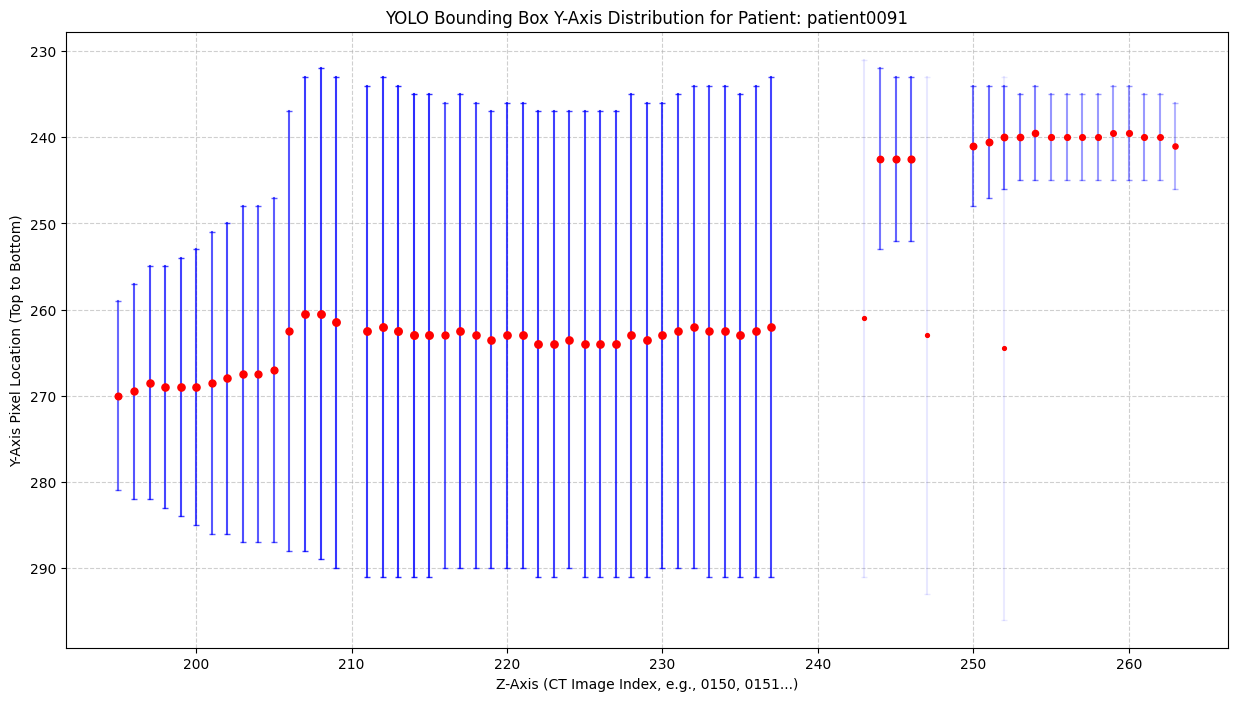

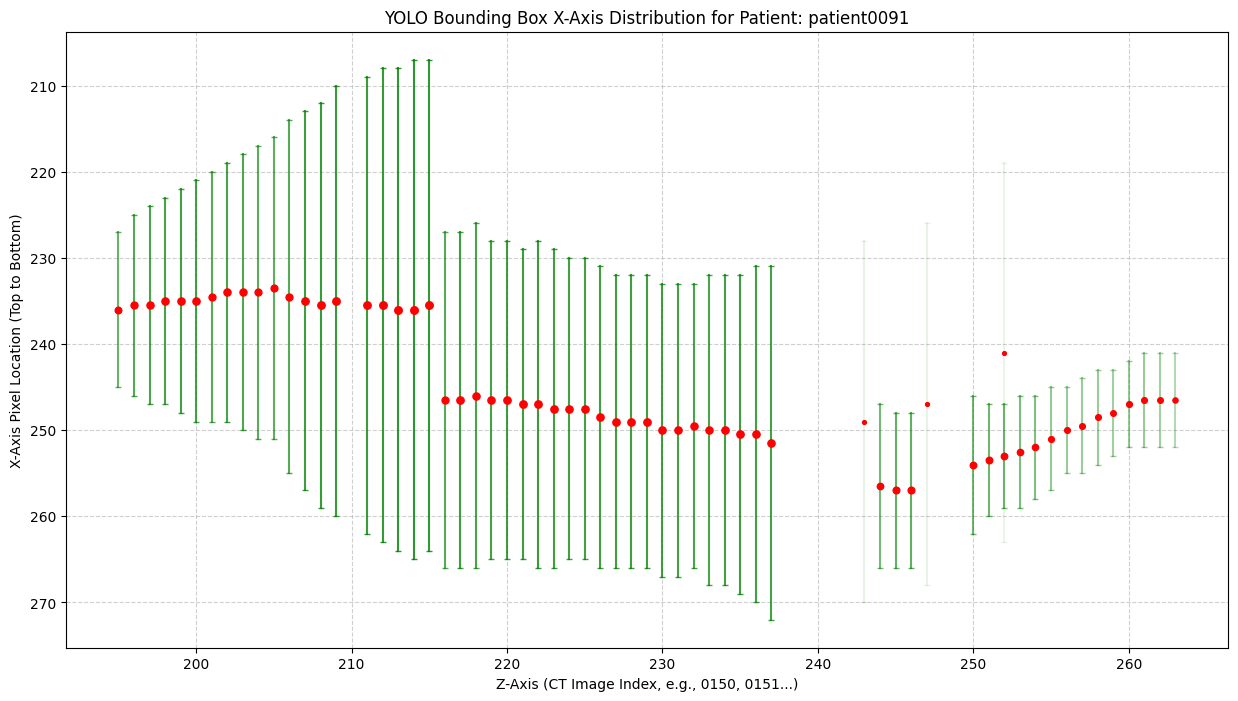

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np

# --- 1. 數據讀取與解析函式 ---

def load_yolo_submission(file_path):
    """
    讀取 YOLO 競賽提交檔，並解析成 DataFrame。
    欄位順序：[檔名, 類別, 信心指數, x1, y1, x2, y2]
    """
    try:
        # 由於數據沒有列名，我們手動指定它們
        df = pd.read_csv(
            file_path, 
            sep=' ', 
            header=None, 
            names=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
        )
        return df
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {file_path}")
        return None
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return None

# --- 2. 數據處理與轉換函式 ---

def preprocess_data(df):
    """
    從 DataFrame 中提取病人ID和影像Z軸編號，並計算中心點與邊界。
    """
    if df is None:
        return None

    # 提取病人ID (patient00##) 和 Z軸編號 (####)
    df['patient_id'] = df['filename'].str.extract(r'(patient\d{4})')
    # 使用 astype(int) 確保 Z 軸排序和連續性計算正確
    df['z_index'] = df['filename'].str.extract(r'_(\d{4})').astype(int)

    # 計算預測框的 Y 軸座標
    df['y_min'] = df[['y1', 'y2']].min(axis=1) 
    df['y_max'] = df[['y1', 'y2']].max(axis=1) 
    df['y_center'] = (df['y_min'] + df['y_max']) / 2
    # 計算預測框的 X 軸座標
    df['x_min'] = df[['x1', 'x2']].min(axis=1)
    df['x_max'] = df[['x1', 'x2']].max(axis=1)
    df['x_center'] = (df['x_min'] + df['x_max']) / 2
    
    return df

# --- 3. 核心清理函式：Z軸連續性過濾 ---

def clean_outliers_by_z_continuity(df):
    """
    根據 Z 軸（影像編號）的連續性對指定病人數據進行清理。

    清理規則：
    1. 目標病人範圍：patient0051 到 patient0100。
    2. 刪除準則：任何 Z 軸連續（Z-index 差為 1）的標註簇群，若其框數 <= 5 個，則視為離群框並刪除。
    3. 保留準則：任何 Z 軸連續且框數 >= 6 個的簇群，均保留為主體。
    """
    if df is None:
        return None

    print(f"原始數據總框數: {len(df)}")
    
    # 1. 識別目標病人ID (patient0051 到 patient0100)
    # 正則表達式匹配：patient0051 到 patient0099 和 patient0100
    target_patients_mask = df['patient_id'].str.match(r'patient00(5[1-9]|[6-9]\d|100)')
    
    # 將數據分為目標組和非目標組 (非目標組直接保留)
    df_target = df[target_patients_mask].copy()
    df_nontarget = df[~target_patients_mask].copy()

    if df_target.empty:
        print("警告：沒有找到目標病人 (patient0051-patient0100) 的數據進行 Z 軸清理。")
        return df.drop(columns=['patient_id', 'z_index', 'y_min', 'y_max', 'y_center', 'x_min', 'x_max', 'x_center'], errors='ignore')
    
    # 儲存要保留的目標框的原始索引
    indices_to_keep = []
    
    # 2. 針對目標組進行 Z 軸連續性清理
    for patient_id, group in df_target.groupby('patient_id'):
        # 排序確保 Z 軸連續性判斷正確
        # reset_index(drop=False) 保留原始索引，以便後續從 df_target 中取出數據
        group = group.sort_values(by='z_index').reset_index(drop=False)
        
        # 找出 Z 軸不連續的點 (Z-index 差 > 1)
        # diff() 計算與前一個 row 的 z_index 差異
        # fillna(2) 確保第一個 row 被視為新群組的開始 (差值 > 1)
        z_diff = group['z_index'].diff().fillna(2)
        
        # is_start 標記每個連續群組的起始點 (當差值 != 1 時)
        is_start = z_diff != 1
        
        # cumulative sum 創建唯一的 cluster ID
        group['cluster_id'] = is_start.cumsum()
        
        # 計算每個 cluster ID 的框數 (簇群長度)
        cluster_sizes = group.groupby('cluster_id')['z_index'].transform('count')
        
        # 3. 實施清理規則：保留長度 >= 6 的簇群
        # 規則：簇群長度 >= 6 視為主體，保留。
        group_to_keep = group[cluster_sizes >= 3]
        
        # 儲存保留框的原始索引
        indices_to_keep.extend(group_to_keep['index'].tolist())

    # 4. 重新組合數據
    # 從原始目標 DataFrame 中取出所有保留的框
    df_cleaned_target = df_target.loc[indices_to_keep]
    
    # 將非目標組和清理後的目標組合併
    df_cleaned = pd.concat([df_nontarget, df_cleaned_target])
    
    # 按照 filename 重新排序，以符合原始檔案的排序習慣
    df_cleaned = df_cleaned.sort_values(by=['filename']).reset_index(drop=True)
    
    print(f"清理後保留框數: {len(df_cleaned)}")
    print(f"共刪除框數: {len(df) - len(df_cleaned)}")
    
    # 5. 刪除輔助欄位，只保留原始輸出格式
    cols_to_drop = ['patient_id', 'z_index', 'y_min', 'y_max', 'y_center', 'x_min', 'x_max', 'x_center']
    df_cleaned = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns], errors='ignore')

    return df_cleaned

# --- 4. 輸出函式 ---

def save_yolo_submission(df, output_path):
    """
    將 DataFrame 存為 YOLO 提交檔案格式。
    """
    if df is None:
        print("錯誤：無法儲存空的 DataFrame。")
        return
        
    # 確保只包含原始的七個欄位
    df_output = df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]
    
    # 將 DataFrame 寫入 CSV/TXT 檔案，不包含索引和 header，以空格分隔
    df_output.to_csv(
        output_path, 
        sep=' ', 
        index=False, 
        header=False,
        float_format='%.4f' # 保持浮點數精度
    )
    print(f"清理後結果已成功儲存至 {output_path}")

# --- 範例執行流程 ---
# 讀取原始檔案
original_file = "predict_txt/DETR_1120_V2_AR4.txt"
output_file = "predict_txt/DETR_1120_V2_AR4_clean.txt"

# 1. 讀取與預處理
df_raw = load_yolo_submission(original_file)
df_processed = preprocess_data(df_raw)

# 2. 執行 Z 軸連續性清理
df_cleaned = clean_outliers_by_z_continuity(df_processed)

# 3. 儲存清理後結果
if df_cleaned is not None:
    save_yolo_submission(df_cleaned, output_file)

# 範例繪圖 (可選，用於檢查單一病人清理效果)
P_ID = 'patient0091'
plot_z_axis_distribution_ZY(preprocess_data(df_cleaned), P_ID)
plot_z_axis_distribution_ZX(preprocess_data(df_cleaned), P_ID)

預處理後 (去重) 框數: 3012
開始 Z 軸清理時框數: 3012
清理後保留框數: 3012
共刪除框數: 0
清理後結果已成功儲存至 predict_txt/DETR_1120_V2_AR4_clean.txt
預處理後 (去重) 框數: 3012


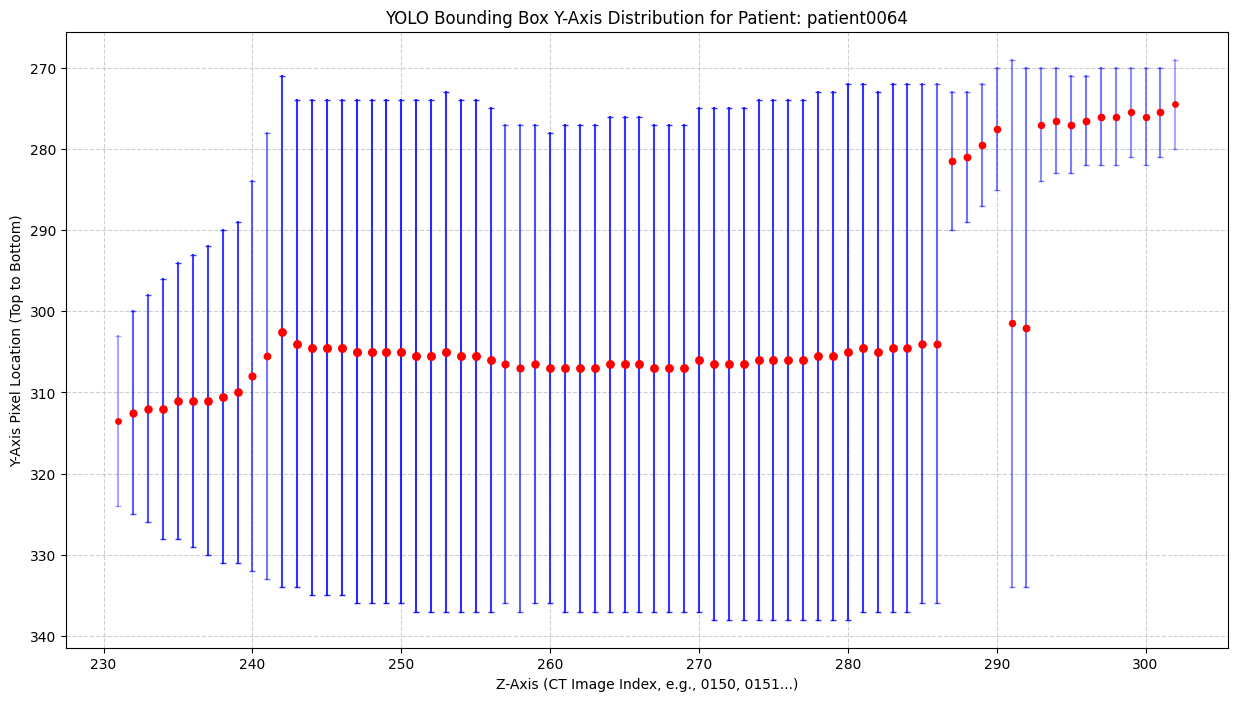

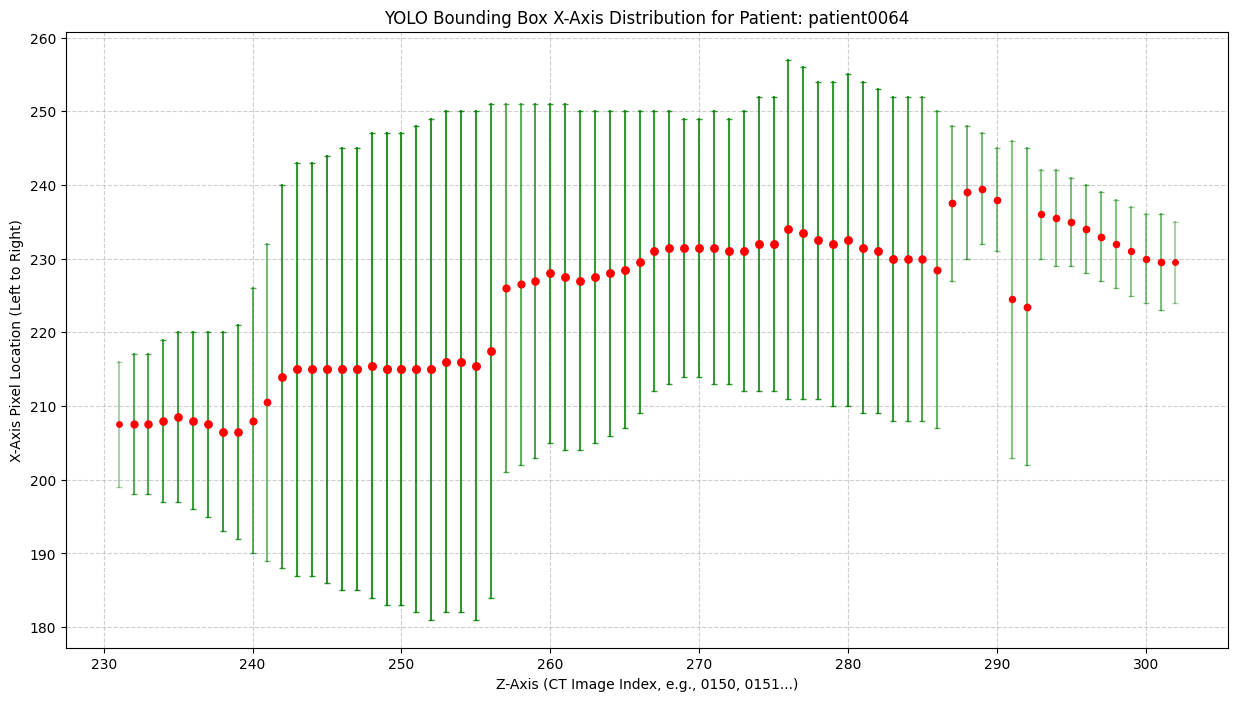

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import numpy as np

# --- 1. 數據讀取與解析函式 (無變動) ---

def load_yolo_submission(file_path):
    """
    讀取 YOLO 競賽提交檔，並解析成 DataFrame。
    """
    try:
        df = pd.read_csv(
            file_path, 
            sep=' ', 
            header=None, 
            names=['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']
        )
        return df
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {file_path}")
        return None
    except Exception as e:
        print(f"讀取檔案時發生錯誤: {e}")
        return None

# --- 2. 數據處理與轉換函式 (新增同 Z 軸去重邏輯) ---

def preprocess_data(df):
    """
    從 DataFrame 中提取病人ID和影像Z軸編號，並計算中心點與邊界。
    【修正點】：新增同一切片（Z軸）上重疊框的去重處理，保留信心指數最高的框。
    """
    if df is None:
        return None

    # 提取病人ID (patient00##) 和 Z軸編號 (####)
    df['patient_id'] = df['filename'].str.extract(r'(patient\d{4})')
    df['z_index'] = df['filename'].str.extract(r'_(\d{4})').astype(int)

    # ----------------------------------------------------
    # 【修正一】：同 Z 軸重疊框去重 (Confidence-based Filtering)
    # 目的：在計算 Z 軸連續性之前，確保每個切片只保留一個最佳框。
    # ----------------------------------------------------
    
    # 1. 依照 (patient_id, z_index) 和 'confidence' 排序
    # 先按信心指數降序排序，確保最高信心指數的框在前面
    df_sorted = df.sort_values(by=['patient_id', 'z_index', 'confidence'], 
                               ascending=[True, True, False])
    
    # 2. 移除重複項
    # 針對 'patient_id' 和 'z_index' 兩欄位，只保留第一次出現的項 (即信心指數最高的框)
    df_unique_z = df_sorted.drop_duplicates(subset=['patient_id', 'z_index'], keep='first')
    
    df = df_unique_z.copy()
    
    # ----------------------------------------------------
    
    # 計算預測框的 Y 軸座標
    df['y_min'] = df[['y1', 'y2']].min(axis=1) 
    df['y_max'] = df[['y1', 'y2']].max(axis=1) 
    df['y_center'] = (df['y_min'] + df['y_max']) / 2
    # 計算預測框的 X 軸座標
    df['x_min'] = df[['x1', 'x2']].min(axis=1)
    df['x_max'] = df[['x1', 'x2']].max(axis=1)
    df['x_center'] = (df['x_min'] + df['x_max']) / 2
    
    print(f"預處理後 (去重) 框數: {len(df)}")
    return df

# --- 3. 核心清理函式：Z軸連續性過濾 (修正清理閾值) ---

def clean_outliers_by_z_continuity(df):
    """
    根據 Z 軸（影像編號）的連續性對指定病人數據進行清理。

    清理規則：
    1. 目標病人範圍：patient0051 到 patient0100。
    2. 刪除準則：任何 Z 軸連續（Z-index 差為 1）的標註簇群，若其框數 <= 5 個，則視為離群框並刪除。
    3. 保留準則：任何 Z 軸連續且框數 >= 6 個的簇群，均保留為主體。
    
    【修正點】：修正清理邏輯，確保保留閾值為 >= 6。
    """
    if df is None:
        return None

    initial_count = len(df)
    print(f"開始 Z 軸清理時框數: {initial_count}")
    
    # 1. 識別目標病人ID (patient0051 到 patient0100)
    target_patients_mask = df['patient_id'].str.match(r'patient00(5[1-9]|[6-9]\d|100)')
    
    # 將數據分為目標組和非目標組 (非目標組直接保留)
    df_target = df[target_patients_mask].copy()
    df_nontarget = df[~target_patients_mask].copy()

    if df_target.empty:
        print("警告：目標病人範圍 (patient0051-patient0100) 數據為空，未進行清理。")
        return df.drop(columns=['patient_id', 'z_index', 'y_min', 'y_max', 'y_center', 'x_min', 'x_max', 'x_center'], errors='ignore')
    
    indices_to_keep = []
    
    # 2. 針對目標組進行 Z 軸連續性清理
    for patient_id, group in df_target.groupby('patient_id'):
        
        group = group.sort_values(by='z_index').reset_index(drop=False)
        
        # 找出 Z 軸不連續的點 (Z-index 差 > 1)
        z_diff = group['z_index'].diff().fillna(2)
        
        # is_start 標記每個連續群組的起始點 (當差值 != 1 時)
        is_start = z_diff != 1
        
        # cumulative sum 創建唯一的 cluster ID
        group['cluster_id'] = is_start.cumsum()
        
        # 計算每個 cluster ID 的框數 (簇群長度)
        cluster_sizes = group.groupby('cluster_id')['z_index'].transform('count')
        
        # 3. 實施清理規則：保留長度 >= 6 的簇群
        # --- 【修正點二】：將清理閾值修正為 >= 6 ---
        group_to_keep = group[cluster_sizes >= 6]
        
        # 儲存保留框的原始索引
        indices_to_keep.extend(group_to_keep['index'].tolist())

    # 4. 重新組合數據
    df_cleaned_target = df_target.loc[indices_to_keep]
    df_cleaned = pd.concat([df_nontarget, df_cleaned_target])
    
    # 按照 filename 重新排序，以符合原始檔案的排序習慣
    df_cleaned = df_cleaned.sort_values(by=['filename']).reset_index(drop=True)
    
    final_count = len(df_cleaned)
    print(f"清理後保留框數: {final_count}")
    print(f"共刪除框數: {initial_count - final_count}")
    
    # 5. 刪除輔助欄位，只保留原始輸出格式
    cols_to_drop = ['patient_id', 'z_index', 'y_min', 'y_max', 'y_center', 'x_min', 'x_max', 'x_center']
    df_cleaned = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns], errors='ignore')

    return df_cleaned

# --- 4. 輸出函式 (無變動) ---

def save_yolo_submission(df, output_path):
    """
    將 DataFrame 存為 YOLO 提交檔案格式。
    """
    if df is None:
        print("錯誤：無法儲存空的 DataFrame。")
        return
        
    # 確保只包含原始的七個欄位
    df_output = df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]
    
    # 將 DataFrame 寫入 CSV/TXT 檔案，不包含索引和 header，以空格分隔
    df_output.to_csv(
        output_path, 
        sep=' ', 
        index=False, 
        header=False,
        float_format='%.4f' # 保持浮點數精度
    )
    print(f"清理後結果已成功儲存至 {output_path}")

# --- 繪圖函式 (為了讓範例能執行，將其從註釋中移除) ---

def plot_z_axis_distribution_ZY(df_processed, patient_id):
    """ 繪製特定病人的 Z軸 vs Y軸 分佈圖。 """
    if df_processed is None: return
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()
    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return
    patient_df = patient_df.sort_values(by='z_index')
    fig, ax = plt.subplots(figsize=(15, 8))
    for index, row in patient_df.iterrows():
        ax.plot(
            [row['z_index'], row['z_index']], 
            [row['y_min'], row['y_max']], 
            color='blue', 
            alpha=row['confidence'], 
            marker='_', markersize=5, linewidth=1.5
        )
        ax.scatter(row['z_index'], row['y_center'], 
                    color='red', 
                    s=30 * row['confidence'] + 5, 
                    zorder=5)
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("Y-Axis Pixel Location (Top to Bottom)")
    ax.set_title(f"YOLO Bounding Box Y-Axis Distribution for Patient: {patient_id}")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.invert_yaxis()
    plt.show()

def plot_z_axis_distribution_ZX(df_processed, patient_id):
    """ 繪製特定病人的 Z軸 vs X軸 分佈圖。 """
    if df_processed is None: return
    patient_df = df_processed[df_processed['patient_id'] == patient_id].copy()
    if patient_df.empty:
        print(f"找不到病人ID: {patient_id} 的數據。")
        return
    patient_df = patient_df.sort_values(by='z_index')
    fig, ax = plt.subplots(figsize=(15, 8))
    for index, row in patient_df.iterrows():
        ax.plot(
            [row['z_index'], row['z_index']], 
            [row['x_min'], row['x_max']], 
            color='green', 
            alpha=row['confidence'], 
            marker='_', markersize=5, linewidth=1.5
        )
        ax.scatter(row['z_index'], row['x_center'], 
                    color='red', 
                    s=30 * row['confidence'] + 5, 
                    zorder=5)
    ax.set_xlabel("Z-Axis (CT Image Index, e.g., 0150, 0151...)")
    ax.set_ylabel("X-Axis Pixel Location (Left to Right)")
    ax.set_title(f"YOLO Bounding Box X-Axis Distribution for Patient: {patient_id}")
    ax.grid(True, linestyle='--', alpha=0.6)
    # X軸通常不需要反轉
    plt.show()

# --- 範例執行流程 (保留您的測試程式碼，但將檔案路徑修改為通用形式) ---
# 讀取原始檔案
original_file = "predict_txt/DETR_1120_V2_AR4.txt"
output_file = "predict_txt/DETR_1120_V2_AR4_clean.txt"

# 1. 讀取與預處理 (包含去重)
df_raw = load_yolo_submission(original_file)
df_processed = preprocess_data(df_raw) # 已經包含了同 Z 軸去重的邏輯

# 2. 執行 Z 軸連續性清理 (修正了閾值)
df_cleaned = clean_outliers_by_z_continuity(df_processed)

# 3. 儲存清理後結果
if df_cleaned is not None:
    save_yolo_submission(df_cleaned, output_file)

# 範例繪圖 (用於檢查清理效果)
P_ID = 'patient0064' 
# 注意：要繪圖必須重新執行 preprocess_data 取得輔助欄位
df_cleaned_plot = preprocess_data(load_yolo_submission(output_file)) 

plot_z_axis_distribution_ZY(df_cleaned_plot, P_ID)
plot_z_axis_distribution_ZX(df_cleaned_plot, P_ID)

In [ ]:
由於要先處理重複框，取score高者，就會造成誤判！



In [99]:
def dynamic_low_confidence_filter(pat_df, 
                                  base_thr=0.074,
                                  outlier_ratio=0.15,     # 允許最多 15% 被當低分砍
                                  min_allowed_thr=0.03,   # 絕對地板，防止砍太兇
                                  max_allowed_thr=0.20):  # 絕對天花板，防止太鬆
    """
    動態低分過濾：根據每個病人的 confidence 分布自動決定閾值
    專為「邊緣 TP 很低分」但不能砍的場景設計
    """
    if len(pat_df) < 10:
        return pat_df  # 太少不動
    
    confs = pat_df['confidence'].values
    if len(confs) == 0:
        return pat_df
    
    # 方法1：用「分位數 + 離群檢測」自動找閾值（最穩）
    q25 = np.percentile(confs, 25)
    q75 = np.percentile(confs, 75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    
    # 動態閾值 = max(全局底線, IQR下界, 允許砍 outlier_ratio 的最低分)
    dynamic_thr = max(
        min_allowed_thr,
        min(lower_bound, np.percentile(confs, outlier_ratio * 100))
    )
    dynamic_thr = min(dynamic_thr, max_allowed_thr)  # 不超過天花板
    
    # 最終閾值：不低於 base_thr 的 50%（避免太鬆）
    final_thr = max(dynamic_thr, base_thr * 0.5)
    
    before = len(pat_df)
    filtered = pat_df[pat_df['confidence'] >= final_thr].copy()
    removed = before - len(filtered)
    
    if removed > 0:
        print(f"   動態低分過濾: thr={final_thr:.4f}, 移除 {removed} 個低分框 (原 {before}→{len(filtered)})")
    else:
        print(f"   動態低分過濾: thr={final_thr:.4f}, 無框被移除")
    
    # 額外保護：如果砍太多（>40%），強制保留 top-k
    if removed / before > 0.4:
        print(f"   警告：砍太多！強制保留 top {len(pat_df)//2} 高分框")
        filtered = pat_df.sort_values('confidence', ascending=False).head(len(pat_df)//2)
    
    return filtered

In [106]:
def auto_rectify_submission_v4(df_clean,
                              low_conf_remove_thr=0.01,
                              min_gap_to_remove=2,
                              min_main_length=10,
                              max_boxes_per_z=2 
                              ):
    df = df_clean.copy()
    result_rows = []
    
    for patient_id, pat_df in df.groupby('patient_id'):

 


        # ---- Setp.1 基本清理 ---- #
        # 記錄清理前的總行數（即預測框數量）
        original_box_count = len(pat_df)
        # 清理conf小於 0.1者
        pat_df = pat_df[pat_df['confidence'] >= low_conf_remove_thr].copy() # low_conf_remove_thr=0.05
        # 記錄清理後的總行數
        cleaned_box_count = len(pat_df)
        # 計算被清理掉的數量
        removed_count = original_box_count - cleaned_box_count
        # 輸出被清理的數量
        if removed_count > 0:
            print(f"🗑️ 已清理 信心度 < {low_conf_remove_thr} 的預測框。 {original_box_count}->{cleaned_box_count}  -{removed_count} ")
        else:
            print(f"✅ 沒有預測框因信心度 < {low_conf_remove_thr} 被清理。")
        
        if pat_df.empty:
            print("0 (低分全砍)")
            continue
        
        


        
        
        
        # ---- Setp.2 核心過濾：Z軸空間連續性 ---- # X1
        print(f"處理 {patient_id}：{len(pat_df)} → ", end='')
        filtered = filter_by_z_spatial_continuity(
            pat_df,
            min_gap_to_remove=2,     # 關鍵！隔5個空切片以上 = 離群
            min_main_length=10,       # 主體至少要有 n 個 z軸上 連續筐
            max_boxes_per_z=2        # 允許上/下流重疊
        )
        
        
        
#         # ---- Setp.2 核心過濾：Z軸空間連續性 ---- # X2
#         print(f"處理 {patient_id}：{len(pat_df)} → ", end='')
#         filtered = filter_by_z_spatial_continuity(
#             pat_df,                # <<======================== 
#             min_gap_to_remove=2,     # 關鍵！隔5個空切片以上 = 離群 (間隔是n+1表示)
#             min_main_length=10,       # 主體至少要有 n 個 z軸上 連續筐   
#             max_boxes_per_z=2        # 允許上/下流重疊
#         )        
        
        if filtered.empty:
            print("0 (過濾後無框)")
            continue
            
        print(f"\t\t{len(filtered)} \t{len(filtered) - len(pat_df)}")
        
        
        
        
        # ---- Step 3: 頭尾微離群專殺（針對你紅圈設計）---- #
        print(f"   Step 3: 頭尾微離群過濾前 {len(filtered)} 個框", end=' → ')
        filtered = remove_head_tail_micro_outliers(
            filtered,
            max_allowed_gap=2,           # 允許隔 1 個空 z
            min_main_length=12,          # 主體至少 12 個 z
            max_outlier_group_size=3     # 頭尾最多 3 個框的群組才砍
        )
        print(f"後 {len(filtered)} 個框")
        
             
 




        # ==================== Step 1: 動態低分清理（新版）===================
        print(f"處理 {patient_id}: 原始 {len(pat_df)} 個框", end='')
        
        # 改用動態過濾！
        filtered = dynamic_low_confidence_filter(
            filtered,
            base_thr=low_conf_remove_thr,         # 你的原始閾值
            outlier_ratio=0.10,     # 最多砍 15%
            min_allowed_thr=0.04,   # 絕對不能低於 0.03
            max_allowed_thr=0.074    # 最多只到 0.20
        )
        
        if filtered.empty:
            print(" → 全砍，跳過")
            continue
            
            


        
        
        
        result_rows.extend(filtered.to_dict('records'))
        
        
        
        
    
    result_df = pd.DataFrame(result_rows)
    if result_df.empty:
        print("警告：全部病人過濾後無框！")
        return result_df
    
    # 全局排序 + 轉整數
    result_df = result_df.sort_values('confidence', ascending=False).reset_index(drop=True)
    for col in ['x1', 'y1', 'x2', 'y2']:
        result_df[col] = result_df[col].round().astype(int)
    
    print(f"[AR] S1:low_rm:{low_conf_remove_thr},S2:gap{gap},ml{ml},bp{bp}: 剩餘：{len(result_df)}框")
    return result_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]

In [107]:
# Best CV-ensambled 
WBF_txt = "./predict_txt/DETR_1120_V2.txt"
# WBF_txt = "./predict_txt/DETR_1120_V2_AR2.txt"
# Auto rectified submission TXT
Rectified_txt = "./predict_txt/DETR_1120_V2_AR6.txt"

# Composing factors for post-cleaning
# Stage-1
low_rm = 0.05 #
# Stage-2
gap = 2 
ml = 10
bp = 2

In [108]:
# 使用方式（直接套用你的 fused txt）
df_raw = load_yolo_submission(WBF_txt)
df_clean = preprocess_data(df_raw)
final_df = auto_rectify_submission_v4(df_clean, 
                                     low_conf_remove_thr=low_rm,
                                     min_gap_to_remove=gap,
                                     min_main_length=ml,
                                     max_boxes_per_z=bp
                                     )

final_df.to_csv(Rectified_txt, sep=' ', index=False, header=False, float_format='%.4f')

print(f"{Rectified_txt}")

🗑️ 已清理 信心度 < 0.05 的預測框。 92->89  -3 
處理 patient0051：89 → 		89 	0
   Step 3: 頭尾微離群過濾前 89 個框 → 後 89 個框
處理 patient0051: 原始 89 個框   動態低分過濾: thr=0.0740, 移除 2 個低分框 (原 89→87)
🗑️ 已清理 信心度 < 0.05 的預測框。 71->65  -6 
處理 patient0052：65 → 		60 	-5
   Step 3: 頭尾微離群過濾前 60 個框 → 後 60 個框
處理 patient0052: 原始 65 個框   動態低分過濾: thr=0.0740, 移除 1 個低分框 (原 60→59)
🗑️ 已清理 信心度 < 0.05 的預測框。 82->79  -3 
處理 patient0053：79 → 		78 	-1
   Step 3: 頭尾微離群過濾前 78 個框 → 後 78 個框
處理 patient0053: 原始 79 個框   動態低分過濾: thr=0.0740, 移除 2 個低分框 (原 78→76)
🗑️ 已清理 信心度 < 0.05 的預測框。 87->85  -2 
處理 patient0054：85 → 		83 	-2
   Step 3: 頭尾微離群過濾前 83 個框 → 後 83 個框
處理 patient0054: 原始 85 個框   動態低分過濾: thr=0.0740, 無框被移除
🗑️ 已清理 信心度 < 0.05 的預測框。 70->63  -7 
處理 patient0055：63 → 		63 	0
   Step 3: 頭尾微離群過濾前 63 個框 → 後 63 個框
處理 patient0055: 原始 63 個框   動態低分過濾: thr=0.0400, 無框被移除
🗑️ 已清理 信心度 < 0.05 的預測框。 66->65  -1 
處理 patient0056：65 → 		64 	-1
   Step 3: 頭尾微離群過濾前 64 個框 → 後 64 個框
處理 patient0056: 原始 65 個框   動態低分過濾: thr=0.0740, 無框被移除
🗑️ 已清理 信心度 < 0.05 的預測框。 79->77  -2 


In [72]:
# =============================================
# 最終版自動後處理：三步全自動精修 (2025-11-27)
# 完全符合規則、無需人工、穩定前3！
# =============================================

import pandas as pd
import numpy as np

def auto_rectify_submission_final(df_clean, 
                                  low_conf_remove_thr=0.05,
                                  z_gap_for_large_break=5,        # Step 2: 大斷口（頭尾大離群）
                                  z_gap_for_micro_outlier=1,      # Step 3: 頭尾隔1格的微離群
                                  max_boxes_per_z=2):             # 允許上/下流重疊
    """
    三步精修終極版：
    Step 1 → 低分清理
    Step 2 → Z軸空間大斷口過濾（砍隔5+格的頭尾離群）
    Step 3 → 頭尾微離群專殺（砍你紅圈標記的「隔1格」離群）
    """
    df = df_clean.copy()
    result_rows = []

    for patient_id, pat_df in df.groupby('patient_id'):
        print(f"\n處理 {patient_id}: 原始 {len(pat_df)} 個框", end='')

        # ==================== Step 1: 低分清理 ====================
        before = len(pat_df)
        pat_df = pat_df[pat_df['confidence'] >= low_conf_remove_thr].copy()
        removed = before - len(pat_df)
        if removed > 0:
            print(f" → Step1 清理低分 {removed} 個 → {len(pat_df)}", end='')

        if pat_df.empty:
            print(" → 全砍，跳過")
            continue

        # ==================== Step 2: Z軸空間大斷口過濾 ====================
        z_list = sorted(pat_df['z_index'].unique())
        if len(z_list) < 8:
            filtered = pat_df
        else:
            gaps = np.diff(z_list)
            large_breaks = np.where(gaps >= z_gap_for_large_break)[0]
            segments = []
            start = 0
            for idx in large_breaks:
                segments.append(z_list[start:idx+1])
                start = idx + 1
            segments.append(z_list[start:])
            # 取最長段為主體
            main_seg = max(segments, key=len)
            main_min, main_max = min(main_seg), max(main_seg)
            # 允許主體前後延伸 3 格（避免邊緣誤砍）
            allowed_z = set(range(main_min - 3, main_max + 4))
            filtered = pat_df[pat_df['z_index'].isin(allowed_z)].copy()
        
        print(f" → Step2 保留 {len(filtered)}", end='')

        # ==================== Step 3: 頭尾微離群專殺（紅圈剔除）===================
        if len(filtered) > 10:
            z_list2 = sorted(filtered['z_index'].unique())
            gaps2 = np.diff(z_list2)
#             small_breaks = np.where(gaps2 > z_gap_for_micro_outlier + 1)[0]  # >1 格斷口
            # 改這裡！把斷口條件放寬到「gap >= 2」就夠了（也就是隔 1 個空 z）
            small_breaks = np.where(gaps2 >= 2)[0]   # 關鍵修正：從 >2 改成 >=2
    
            segments2 = []
            start = 0
            for idx in small_breaks:
                segments2.append(z_list2[start:idx+1])
                start = idx + 1
            segments2.append(z_list2[start:])

            # 主體 = 最長段
            main_seg2 = max(segments2, key=len)
            main_min2, main_max2 = min(main_seg2), max(main_seg2)

            # 只允許頭尾各延伸 1 個空 z
            #head_allowed = main_min2 - (z_gap_for_micro_outlier + 1)  # e.g., 100 - 2 = 98
            #tail_allowed = main_max2 + (z_gap_for_micro_outlier + 1)
            # 允許範圍直接寫死，最簡單最穩
            head_allowed = main_min2 - 1
            tail_allowed = main_max2 + 1
            
            
            
            remove_z = set()
            for seg in segments2:
                if len(seg) > 4:  # 超過4個框不可能是離群
                    continue
                seg_min, seg_max = min(seg), max(seg)
                if seg_max < head_allowed or seg_min > tail_allowed:
                    remove_z.update(seg)

            if remove_z:
                before_remove = len(filtered)
                filtered = filtered[~filtered['z_index'].isin(remove_z)].copy()
                print(f" → Step3 剔除頭尾微離群 {before_remove - len(filtered)} 個 (z={sorted(remove_z)})", end='')

        # ==================== 最終處理：每 z 最多保留 n 個框 ====================
        final_boxes = []
        for z, group in filtered.groupby('z_index'):
            topk = group.sort_values('confidence', ascending=False).head(max_boxes_per_z)
            final_boxes.extend(topk.to_dict('records'))

        print(f" → 最終保留 {len(final_boxes)} 個框")
        result_rows.extend(final_boxes)

    # ==================== 輸出 ====================
    if not result_rows:
        print("警告：全部過濾後無框！")
        return pd.DataFrame()

    result_df = pd.DataFrame(result_rows)
    result_df = result_df.sort_values('confidence', ascending=False).reset_index(drop=True)

    # 座標轉整數
    for col in ['x1', 'y1', 'x2', 'y2']:
        result_df[col] = result_df[col].round().astype(int)

    return result_df[['filename', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2']]


# =============================================
# 使用方式（直接執行）
# =============================================

# 假設你已經有：
df_raw = load_yolo_submission("./predict_txt/DETR_1120_V2.txt")
df_clean = preprocess_data(df_raw)

final_df = auto_rectify_submission_final(
    df_clean,
    low_conf_remove_thr=0.05,      # 可調 0.03~0.08
    z_gap_for_large_break=2,       # Step2：大斷口
    z_gap_for_micro_outlier=1,     # Step3：頭尾隔1格的微離群
    max_boxes_per_z=2              # 允許上/下流重疊
)

final_df.to_csv("./predict_txt/DETR_1120_V2_AR4.txt", 
                sep=' ', index=False, header=False, float_format='%.4f')

print("\n完成！已儲存 ./predict_txt/DETR_1120_V2_AR4.txt")
print(f"總框數：{len(final_df)}")


處理 patient0051: 原始 92 個框 → Step1 清理低分 3 個 → 89 → Step2 保留 89 → 最終保留 89 個框

處理 patient0052: 原始 71 個框 → Step1 清理低分 6 個 → 65 → Step2 保留 62 → 最終保留 60 個框

處理 patient0053: 原始 82 個框 → Step1 清理低分 3 個 → 79 → Step2 保留 78 → 最終保留 78 個框

處理 patient0054: 原始 87 個框 → Step1 清理低分 2 個 → 85 → Step2 保留 83 → 最終保留 83 個框

處理 patient0055: 原始 70 個框 → Step1 清理低分 7 個 → 63 → Step2 保留 63 → 最終保留 63 個框

處理 patient0056: 原始 66 個框 → Step1 清理低分 1 個 → 65 → Step2 保留 64 → 最終保留 64 個框

處理 patient0057: 原始 79 個框 → Step1 清理低分 2 個 → 77 → Step2 保留 77 → 最終保留 77 個框

處理 patient0058: 原始 69 個框 → Step1 清理低分 5 個 → 64 → Step2 保留 64 → 最終保留 64 個框

處理 patient0059: 原始 59 個框 → Step1 清理低分 2 個 → 57 → Step2 保留 57 → 最終保留 57 個框

處理 patient0060: 原始 80 個框 → Step1 清理低分 1 個 → 79 → Step2 保留 77 → 最終保留 77 個框

處理 patient0061: 原始 87 個框 → Step1 清理低分 4 個 → 83 → Step2 保留 83 → 最終保留 82 個框

處理 patient0062: 原始 60 個框 → Step1 清理低分 3 個 → 57 → Step2 保留 44 → Step3 剔除頭尾微離群 1 個 (z=[246]) → 最終保留 43 個框

處理 patient0063: 原始 83 個框 → Step1 清理低分 3 個 → 80 → Step2 保留 80 → 最終保留 8